# Inicjalizacja | Feature Engineering | XGBoost

In [1]:
import pandas as pd
import numpy as np
import glob
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight

print("="*80)
print(">>> KROK 1: PRZYGOTOWANIE DANYCH I TRENING XGBOOST <<<")
print("="*80)

# 1. WCZYTANIE DANYCH 
df_train_raw = pd.read_csv('../dane/gotowe_ml/honeypot_ground_truth_final.csv')
df_train_raw = df_train_raw[df_train_raw['Refined_Label'] != 'Background Noise'].copy()

test_files = glob.glob('../dane/testowe/*.csv')
dfs_test = [pd.read_csv(f, on_bad_lines="skip", low_memory=False) for f in test_files]
df_test_raw = pd.concat(dfs_test, ignore_index=True) if dfs_test else pd.DataFrame()

# 2. WSPÓLNA INŻYNIERIA CECH 
known_protos = {p: i for i, p in enumerate(df_train_raw['Proto'].astype(str).unique())}
known_states = {s: i for i, s in enumerate(df_train_raw['State'].astype(str).unique())}

def safe_encode(val, mapping_dict): return mapping_dict.get(str(val), -1)
def safe_port(p):
    try: return int(str(p), 16) if str(p).startswith('0x') else int(float(p))
    except: return 0

FEATURES = ['Dur', 'TotPkts', 'TotBytes', 'SrcPkts', 'DstPkts', 'Bytes_per_Pkt', 'Pkts_Freq', 'Pkts_Ratio', 'Proto_Enc', 'State_Enc', 'Dport_Num']

def prepare_xgb_features(df_input):
    df = df_input.copy()
    for col in ['Dur', 'TotPkts', 'TotBytes', 'SrcPkts', 'DstPkts']:
        df[col] = pd.to_numeric(df.get(col, 0), errors='coerce').fillna(0)
    
    df['Bytes_per_Pkt'] = df['TotBytes'] / (df['TotPkts'] + 1e-6)
    df['Pkts_Freq']     = df['TotPkts'] / (df['Dur'] + 1e-6)
    df['Pkts_Ratio']    = df['SrcPkts'] / (df['DstPkts'] + 1e-6)
    
    df['Proto_Enc'] = df.get('Proto', '').apply(lambda x: safe_encode(x, known_protos))
    df['State_Enc'] = df.get('State', '').apply(lambda x: safe_encode(x, known_states))
    df['Dport_Num'] = df.get('Dport', 0).apply(safe_port)
    return df

df_train = prepare_xgb_features(df_train_raw)
df_test = prepare_xgb_features(df_test_raw)

X_train = df_train[FEATURES].fillna(0)

# Kodowanie etykiet (Wymóg XGBoost)
le_target = LabelEncoder()
y_train_encoded = le_target.fit_transform(df_train['Refined_Label'])
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train_encoded)

# 3. TRENING MODELU
print("[*] Trenowanie modelu XGBoost (Gradien Boosting)...")
xgb_clf = xgb.XGBClassifier(
    n_estimators=100, learning_rate=0.1, max_depth=6, 
    random_state=42, n_jobs=-1, eval_metric='mlogloss'
)
xgb_clf.fit(X_train, y_train_encoded, sample_weight=sample_weights)
print("[+] Model XGBoost gotowy i uzbrojony!")

>>> KROK 1: PRZYGOTOWANIE DANYCH I TRENING XGBOOST <<<
[*] Trenowanie modelu XGBoost (Gradien Boosting)...
[+] Model XGBoost gotowy i uzbrojony!


# Wykresy ROC i PR

>>> KROK 2: EWALUACJA XGBOOST (ROC / PR CURVES) <<<


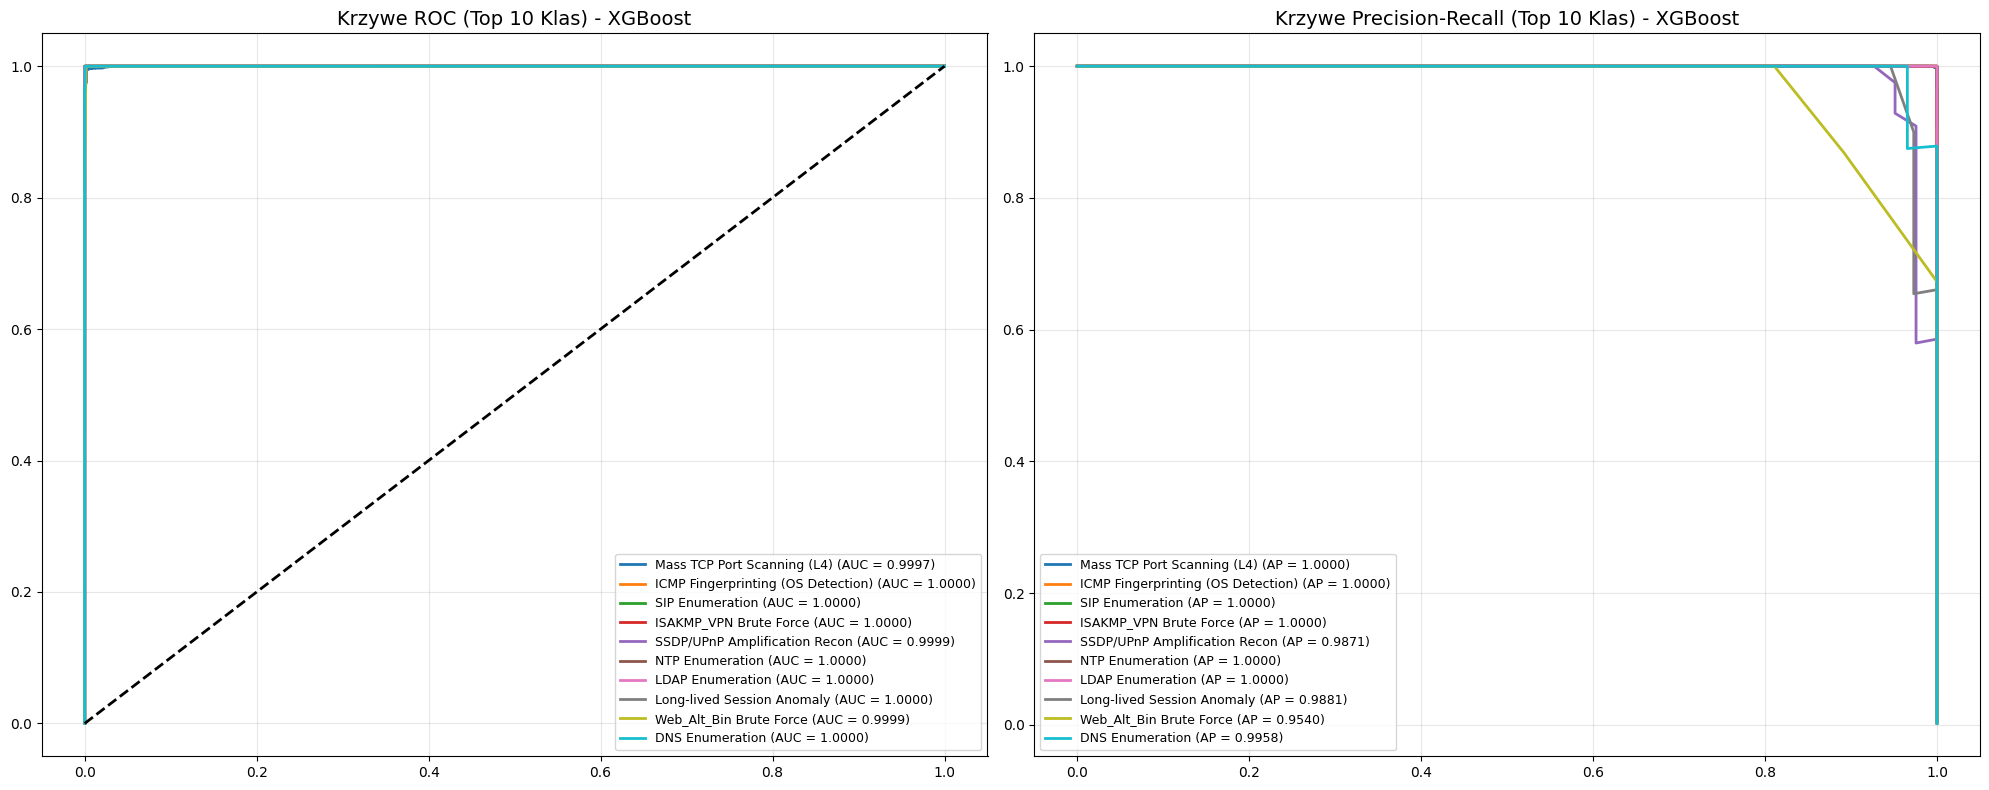

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns
import os

print("="*80)
print(">>> KROK 2: EWALUACJA XGBOOST (ROC / PR CURVES) <<<")
print("="*80)

output_dir = '../wykresy'
if not os.path.exists(output_dir): os.makedirs(output_dir)

X_train_ev, X_test_ev, y_train_ev, y_test_ev = train_test_split(
    X_train, y_train_encoded, test_size=0.20, random_state=42, stratify=y_train_encoded
)

# Model ewaluacyjny
xgb_eval = xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42, n_jobs=-1)
sample_weights_ev = compute_sample_weight(class_weight='balanced', y=y_train_ev)
xgb_eval.fit(X_train_ev, y_train_ev, sample_weight=sample_weights_ev)

# Metryki
classes_num = xgb_eval.classes_
y_test_bin = label_binarize(y_test_ev, classes=classes_num)
n_classes = y_test_bin.shape[1]
y_score = xgb_eval.predict_proba(X_test_ev)

fpr, tpr, roc_auc, precision, recall, average_precision = dict(), dict(), dict(), dict(), dict(), dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    precision[i], recall[i], _ = precision_recall_curve(y_test_bin[:, i], y_score[:, i])
    average_precision[i] = average_precision_score(y_test_bin[:, i], y_score[:, i])

top_classes_names = df_train['Refined_Label'].value_counts().head(10).index
top_classes_idx = le_target.transform(top_classes_names)
colors = sns.color_palette("tab10", len(top_classes_idx))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

for idx, color, name in zip(top_classes_idx, colors, top_classes_names):
    ax1.plot(fpr[idx], tpr[idx], color=color, lw=2, label=f'{name} (AUC = {roc_auc[idx]:.4f})')
ax1.plot([0, 1], [0, 1], 'k--', lw=2)
ax1.set_title('Krzywe ROC (Top 10 Klas) - XGBoost', fontsize=14)
ax1.legend(loc="lower right", fontsize=9)
ax1.grid(alpha=0.3)

for idx, color, name in zip(top_classes_idx, colors, top_classes_names):
    ax2.plot(recall[idx], precision[idx], color=color, lw=2, label=f'{name} (AP = {average_precision[idx]:.4f})')
ax2.set_title('Krzywe Precision-Recall (Top 10 Klas) - XGBoost', fontsize=14)
ax2.legend(loc="lower left", fontsize=9)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, '10_xgboost_roc_pr_curves.png'), dpi=300)
plt.show()

# Inferencja i Paszport DPI

In [3]:
print("="*100)
print(">>> KROK 3: INFERENCJA ZERO-DAY I WERYFIKACJA DPI (XGBOOST) <<<")
print("="*100)

X_new = df_test[FEATURES].fillna(0)
CONFIDENCE_THRESHOLD = 0.75

probs = xgb_clf.predict_proba(X_new)
max_probs = np.max(probs, axis=1)
pred_indices = np.argmax(probs, axis=1)

predicted_text_classes = le_target.inverse_transform(pred_indices)
df_test_raw['XGB_Decision'] = np.where(max_probs >= CONFIDENCE_THRESHOLD, predicted_text_classes, 'UNKNOWN_Zero_Day')

# Raport tekstowy
report_counts = df_test_raw['XGB_Decision'].value_counts()
unknown_pct = (report_counts.get('UNKNOWN_Zero_Day', 0) / len(df_test_raw)) * 100
print(f"[!] Ruch odrzucony jako UNKNOWN (XGBoost): {unknown_pct:.2f}%\n")

# Paszport DPI
def get_mode(x):
    m = pd.Series.mode(x)
    return m.iloc[0] if not m.empty else "N/A"

report_xgb = df_test_raw.groupby('XGB_Decision').agg({
    'Dur': 'median', 'TotPkts': 'median', 'State': get_mode, 'Dport': get_mode,
    'srcUdata': lambda x: x.dropna().iloc[0] if not x.dropna().empty else "[Brak Payloadu]"
}).reset_index()

report_xgb['Liczność'] = report_xgb['XGB_Decision'].map(report_counts)
report_xgb = report_xgb.sort_values(by='Liczność', ascending=False)

print(f"{'DECYZJA MODELU XGBOOST':<35} | {'LICZNOŚĆ':<9} | {'PORT':<6} | {'PKT':<4} | {'STATE':<6} | {'PRÓBKA Z PAYLOADU (DPI)'}")
print("-" * 120)

for _, row in report_xgb.iterrows():
    p_clean = str(row['srcUdata']).replace('\n', ' ').replace('\r', ' ')
    p_clean = p_clean[:37] + "..." if len(p_clean) > 40 else p_clean
    print(f"{str(row['XGB_Decision']):<35} | {int(row['Liczność']):<9} | {str(row['Dport']):<6} | {int(row['TotPkts']):<4} | {str(row['State']):<6} | {p_clean}")
print("="*120)

>>> KROK 3: INFERENCJA ZERO-DAY I WERYFIKACJA DPI (XGBOOST) <<<
[!] Ruch odrzucony jako UNKNOWN (XGBoost): 12.87%

DECYZJA MODELU XGBOOST              | LICZNOŚĆ  | PORT   | PKT  | STATE  | PRÓBKA Z PAYLOADU (DPI)
------------------------------------------------------------------------------------------------------------------------
Mass TCP Port Scanning (L4)         | 31809     | 445    | 3    | SR_RA  | s[2]=..
UNKNOWN_Zero_Day                    | 5703      | 135    | 1    | INT    | s[26]=.............1............
UDP_Port_5080 Enumeration           | 2804      | 5080   | 1    | INT    | s[414]=INVITE sip:3293520263@128.199....
SIP Enumeration                     | 1272      | 5060   | 1    | INT    | s[418]=OPTIONS sip:100@128.199.172.15...
ICMP Fingerprinting (OS Detection)  | 584       | 0x0400 | 2    | ECO    | s[64]=......L..zzF.g....................
SSDP/UPnP Amplification Recon       | 527       | 1900   | 1    | INT    | s[99]=M-SEARCH * HTTP/1.1..Host:239.2...
SMB Anomal